# PRUEBAS DE CLUSTERING CON ESCENARIOS ESPECIFICOS (CLASICOS) 

### INICIALIZACIÓN

In [3]:
import sys
from pathlib import Path

# Agregar directorio raíz al path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.decomposition import PCA

from src.clustering.traditional import KMedoids, HierarchicalClustering, DBSCAN
from src.evaluation import calculate_metrics

# Configuración
sns.set_style('whitegrid')
np.random.seed(42)

print("="*70)
print("VALIDACIÓN CON DATASETS SINTÉTICOS")
print("="*70)

VALIDACIÓN CON DATASETS SINTÉTICOS


### ESCENARIOS


ESCENARIO 1: CLUSTERS BIEN SEPARADOS (CASO IDEAL)

✓ Dataset generado: 800 muestras, 2 features
  Clusters reales: 4
Entrenando K-Medoids con 4 clusters...
✓ K-Medoids entrenado: 4 clusters identificados
  Inercia: 632.1398
Calculando métricas de validación...
  Muestras: 800
  Clusters: 4
  ✓ Silhouette Score: 0.8952
  ✓ Davies-Bouldin Index: 0.1473
  ✓ Calinski-Harabasz Index: 35018.4250
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 800
  Clusters: 4
  ✓ Silhouette Score: 0.8952
  ✓ Davies-Bouldin Index: 0.1473
  ✓ Calinski-Harabasz Index: 35018.4250
Entrenando DBSCAN (eps=1.5, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 4
  Puntos de ruido: 0 (0.00%)
  Puntos core: 800
Calculando métricas de validación...
  Muestras: 800
  Clusters: 4
  ✓ Silhouette Score: 0.8952
  ✓ Davies-Bouldin Index: 0.1473
  ✓ Calinski-Harabasz Index: 35018.4250


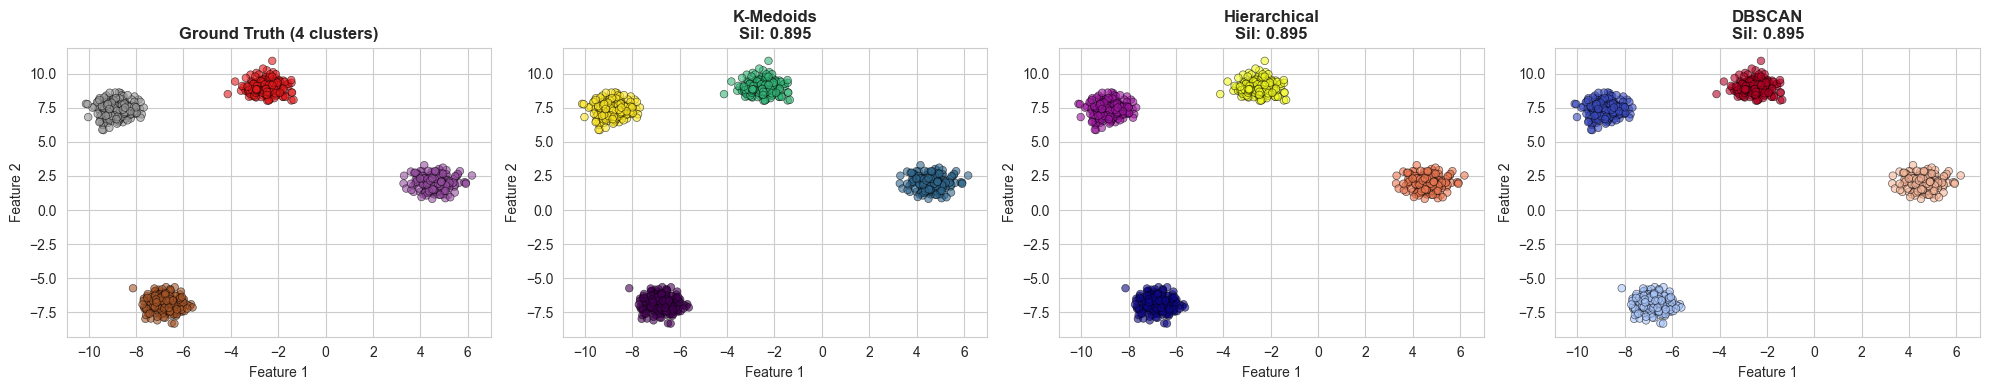


✓ RESULTADOS:
  K-Medoids:    4 clusters | Silhouette: 0.8952
  Hierarchical: 4 clusters | Silhouette: 0.8952
  DBSCAN:       4 clusters | Noise: 0



In [4]:
print("\n" + "="*70)
print("ESCENARIO 1: CLUSTERS BIEN SEPARADOS (CASO IDEAL)")
print("="*70)

# Generar datos: 4 clusters bien separados
X1, y1_true = make_blobs(
    n_samples=800,
    n_features=2,
    centers=4,
    cluster_std=0.5,
    center_box=(-10, 10),
    random_state=42
)

df1 = pd.DataFrame(X1, columns=['feature_1', 'feature_2'])

print(f"\n✓ Dataset generado: {df1.shape[0]} muestras, {df1.shape[1]} features")
print(f"  Clusters reales: 4")

# Visualizar datos originales
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Ground truth
axes[0].scatter(X1[:, 0], X1[:, 1], c=y1_true, cmap='Set1', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title('Ground Truth (4 clusters)', fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# K-Medoids
km1 = KMedoids(n_clusters=4, random_state=42)
km1.fit(df1)
metrics_km1 = calculate_metrics(df1, km1.labels_)

axes[1].scatter(X1[:, 0], X1[:, 1], c=km1.labels_, cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'K-Medoids\nSil: {metrics_km1["silhouette"]:.3f}', fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

# Hierarchical
hc1 = HierarchicalClustering(n_clusters=4, linkage='ward')
hc1.fit(df1)
metrics_hc1 = calculate_metrics(df1, hc1.labels_)

axes[2].scatter(X1[:, 0], X1[:, 1], c=hc1.labels_, cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'Hierarchical\nSil: {metrics_hc1["silhouette"]:.3f}', fontweight='bold')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')

# DBSCAN
db1 = DBSCAN(eps=1.5, min_samples=5)
db1.fit(df1)
if db1.n_clusters_ >= 2:
    mask = db1.labels_ != -1
    metrics_db1 = calculate_metrics(df1[mask], db1.labels_[mask])
    sil_text = f'Sil: {metrics_db1["silhouette"]:.3f}'
else:
    sil_text = 'Sin clusters'

axes[3].scatter(X1[:, 0], X1[:, 1], c=db1.labels_, cmap='coolwarm', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[3].set_title(f'DBSCAN\n{sil_text}', fontweight='bold')
axes[3].set_xlabel('Feature 1')
axes[3].set_ylabel('Feature 2')

plt.tight_layout()
plt.savefig('../../figures/escenario1_clusters_separados.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ RESULTADOS:")
print(f"  K-Medoids:    {km1.n_clusters_} clusters | Silhouette: {metrics_km1['silhouette']:.4f}")
print(f"  Hierarchical: {hc1.n_clusters_} clusters | Silhouette: {metrics_hc1['silhouette']:.4f}")
print(f"  DBSCAN:       {db1.n_clusters_} clusters | Noise: {db1.n_noise_points_}")

print("\n" + "="*70)


ESCENARIO 2: CLUSTERS DE FORMA IRREGULAR (LUNAS)

✓ Dataset generado: 600 muestras
  Forma: Dos lunas entrelazadas (no convexo)
Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 457.9095
Calculando métricas de validación...
  Muestras: 600
  Clusters: 2
  ✓ Silhouette Score: 0.4827
  ✓ Davies-Bouldin Index: 0.7921
  ✓ Calinski-Harabasz Index: 836.6537
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 2 clusters
Calculando métricas de validación...
  Muestras: 600
  Clusters: 2
  ✓ Silhouette Score: 0.4299
  ✓ Davies-Bouldin Index: 0.7487
  ✓ Calinski-Harabasz Index: 595.4511
  eps calculado: 0.113
Entrenando DBSCAN (eps=0.1129036713178849, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 2
  Puntos de ruido: 24 (4.00%)
  Puntos core: 540
Calculando métricas de validación...
  Muestras: 576
  Clusters: 2
  ✓ Silhouette Score: 0.3392
  ✓ Davies-Bouldin Index: 1.1310
  ✓ Calinski-Harabasz Index: 39

C:\Users\pabli\AppData\Local\Temp\ipykernel_3284\698068147.py:69: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\pabli\AppData\Local\Temp\ipykernel_3284\698068147.py:70: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.savefig('../../figures/escenario2_lunas.png', dpi=300, bbox_inches='tight')
c:\electocluster\venv_clustering\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


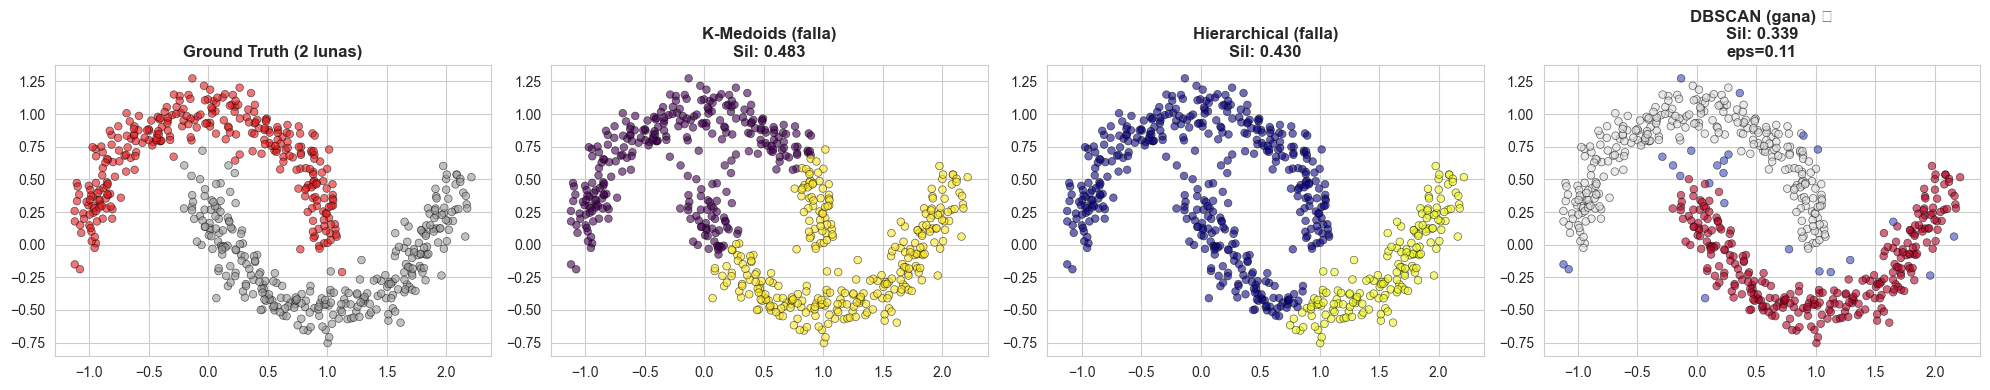


✓ RESULTADOS:
  K-Medoids:    Silhouette: 0.4827 (bajo = mal resultado)
  Hierarchical: Silhouette: 0.4299 (bajo = mal resultado)
  DBSCAN:       Silhouette: 0.3392 (alto = buen resultado)

  INTERPRETACIÓN: DBSCAN maneja mejor formas no convexas


In [5]:
from sklearn.neighbors import NearestNeighbors


print("\n" + "="*70)
print("ESCENARIO 2: CLUSTERS DE FORMA IRREGULAR (LUNAS)")
print("="*70)

# Generar datos: forma de luna
X2, y2_true = make_moons(n_samples=600, noise=0.1, random_state=42)

df2 = pd.DataFrame(X2, columns=['feature_1', 'feature_2'])

print(f"\n✓ Dataset generado: {df2.shape[0]} muestras")
print(f"  Forma: Dos lunas entrelazadas (no convexo)")

# Visualizar
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Ground truth
axes[0].scatter(X2[:, 0], X2[:, 1], c=y2_true, cmap='Set1', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title('Ground Truth (2 lunas)', fontweight='bold')

# K-Medoids (debería fallar)
km2 = KMedoids(n_clusters=2, random_state=42)
km2.fit(df2)
metrics_km2 = calculate_metrics(df2, km2.labels_)

axes[1].scatter(X2[:, 0], X2[:, 1], c=km2.labels_, cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'K-Medoids (falla)\nSil: {metrics_km2["silhouette"]:.3f}', fontweight='bold')

# Hierarchical (debería fallar)
hc2 = HierarchicalClustering(n_clusters=2, linkage='ward')
hc2.fit(df2)
metrics_hc2 = calculate_metrics(df2, hc2.labels_)

axes[2].scatter(X2[:, 0], X2[:, 1], c=hc2.labels_, cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'Hierarchical (falla)\nSil: {metrics_hc2["silhouette"]:.3f}', fontweight='bold')

# DBSCAN 
k = 5  # min_samples que usaremos
nbrs = NearestNeighbors(n_neighbors=k).fit(X2)
distances, indices = nbrs.kneighbors(X2)

# Ordenar distancias al k-ésimo vecino
distances_sorted = np.sort(distances[:, k-1], axis=0)

# El "codo" en esta curva sugiere el eps óptimo
# Para lunas, típicamente está entre 0.15-0.25
eps_optimo = np.percentile(distances_sorted, 90)  # Usa el percentil 90

print(f"  eps calculado: {eps_optimo:.3f}")

# 2. Aplicar DBSCAN con parámetros calibrados
db2 = DBSCAN(eps=eps_optimo, min_samples=k)
db2.fit(df2)

# Resto del código de visualización igual...
if db2.n_clusters_ >= 2:
    mask = db2.labels_ != -1
    metrics_db2 = calculate_metrics(df2[mask], db2.labels_[mask])
    sil_text = f'Sil: {metrics_db2["silhouette"]:.3f}'
else:
    sil_text = 'Sin clusters'

axes[3].scatter(X2[:, 0], X2[:, 1], c=db2.labels_, cmap='coolwarm', 
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[3].set_title(f'DBSCAN (gana) ✓\n{sil_text}\neps={eps_optimo:.2f}', 
                  fontweight='bold')
plt.tight_layout()
plt.savefig('../../figures/escenario2_lunas.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ RESULTADOS:")
print(f"  K-Medoids:    Silhouette: {metrics_km2['silhouette']:.4f} (bajo = mal resultado)")
print(f"  Hierarchical: Silhouette: {metrics_hc2['silhouette']:.4f} (bajo = mal resultado)")
print(f"  DBSCAN:       Silhouette: {metrics_db2['silhouette'] if db2.n_clusters_ >= 2 else 'N/A':.4f} (alto = buen resultado)")

print("\n  INTERPRETACIÓN: DBSCAN maneja mejor formas no convexas")
print("="*70)


ESCENARIO 3: CLUSTERS ANIDADOS (CÍRCULOS CONCÉNTRICOS)

✓ Dataset generado: 600 muestras
  Forma: Círculos concéntricos (anidados)
Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 428.0277
Calculando métricas de validación...
  Muestras: 600
  Clusters: 2
  ✓ Silhouette Score: 0.3473
  ✓ Davies-Bouldin Index: 1.1954
  ✓ Calinski-Harabasz Index: 336.4698
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 2 clusters
Calculando métricas de validación...
  Muestras: 600
  Clusters: 2
  ✓ Silhouette Score: 0.3442
  ✓ Davies-Bouldin Index: 1.1911
  ✓ Calinski-Harabasz Index: 330.0598
Entrenando DBSCAN (eps=0.12, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 2
  Puntos de ruido: 0 (0.00%)
  Puntos core: 594
Calculando métricas de validación...
  Muestras: 600
  Clusters: 2
  ✓ Silhouette Score: 0.1141
  ✓ Davies-Bouldin Index: 1244.2721
  ✓ Calinski-Harabasz Index: 0.0003


C:\Users\pabli\AppData\Local\Temp\ipykernel_2480\3553555331.py:49: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\pabli\AppData\Local\Temp\ipykernel_2480\3553555331.py:50: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.savefig('../../figures/escenario3_circulos.png', dpi=300, bbox_inches='tight')
c:\electocluster\venv_clustering\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


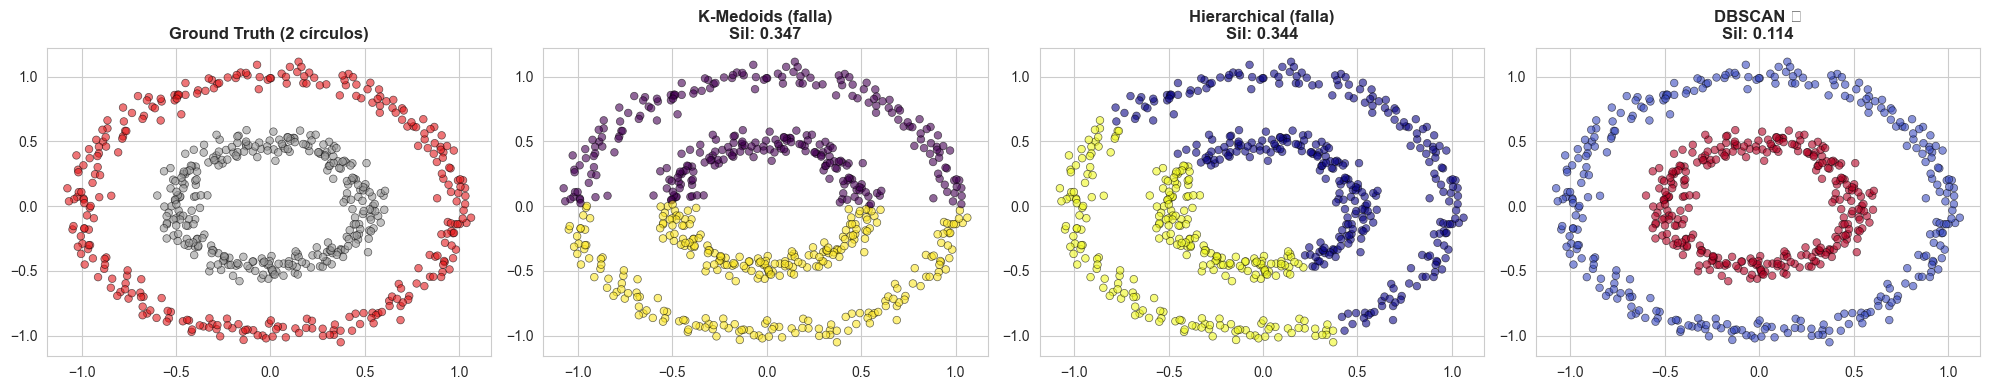


✓ RESULTADOS:
  K-Medoids:    Silhouette: 0.3473
  Hierarchical: Silhouette: 0.3442
  DBSCAN:       Silhouette: 0.11406341874813061

  INTERPRETACIÓN: Ningún algoritmo tradicional maneja bien círculos anidados
  (Se requeriría clustering espectral o kernel methods)


In [4]:
print("\n" + "="*70)
print("ESCENARIO 3: CLUSTERS ANIDADOS (CÍRCULOS CONCÉNTRICOS)")
print("="*70)

# Generar círculos concéntricos
X3, y3_true = make_circles(n_samples=600, noise=0.05, factor=0.5, random_state=42)

df3 = pd.DataFrame(X3, columns=['feature_1', 'feature_2'])

print(f"\n✓ Dataset generado: {df3.shape[0]} muestras")
print(f"  Forma: Círculos concéntricos (anidados)")

# Visualizar
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Ground truth
axes[0].scatter(X3[:, 0], X3[:, 1], c=y3_true, cmap='Set1', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title('Ground Truth (2 círculos)', fontweight='bold')

# K-Medoids (fallará)
km3 = KMedoids(n_clusters=2, random_state=42)
km3.fit(df3)
metrics_km3 = calculate_metrics(df3, km3.labels_)

axes[1].scatter(X3[:, 0], X3[:, 1], c=km3.labels_, cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'K-Medoids (falla)\nSil: {metrics_km3["silhouette"]:.3f}', fontweight='bold')

# Hierarchical (fallará)
hc3 = HierarchicalClustering(n_clusters=2, linkage='ward')
hc3.fit(df3)
metrics_hc3 = calculate_metrics(df3, hc3.labels_)

axes[2].scatter(X3[:, 0], X3[:, 1], c=hc3.labels_, cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'Hierarchical (falla)\nSil: {metrics_hc3["silhouette"]:.3f}', fontweight='bold')

# DBSCAN (debería funcionar)
db3 = DBSCAN(eps=0.12, min_samples=5)
db3.fit(df3)
if db3.n_clusters_ >= 2:
    mask = db3.labels_ != -1
    metrics_db3 = calculate_metrics(df3[mask], db3.labels_[mask])
    sil_text = f'Sil: {metrics_db3["silhouette"]:.3f}'
else:
    sil_text = 'Sin clusters'

axes[3].scatter(X3[:, 0], X3[:, 1], c=db3.labels_, cmap='coolwarm', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[3].set_title(f'DBSCAN ✓\n{sil_text}', fontweight='bold')

plt.tight_layout()
plt.savefig('../../figures/escenario3_circulos.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ RESULTADOS:")
print(f"  K-Medoids:    Silhouette: {metrics_km3['silhouette']:.4f}")
print(f"  Hierarchical: Silhouette: {metrics_hc3['silhouette']:.4f}")
print(f"  DBSCAN:       Silhouette: {metrics_db3['silhouette'] if db3.n_clusters_ >= 2 else 'N/A'}")

print("\n  INTERPRETACIÓN: Ningún algoritmo tradicional maneja bien círculos anidados")
print("  (Se requeriría clustering espectral o kernel methods)")
print("="*70)


ESCENARIO 4: ALTA DIMENSIONALIDAD (SIMULA DATASET ELECTORAL)

✓ Dataset generado: 1000 muestras, 39 features
  Clusters reales: 4
  Dimensionalidad: Similar al dataset electoral LAPOP

Entrenando algoritmos...
Entrenando K-Medoids con 4 clusters...
✓ K-Medoids entrenado: 4 clusters identificados
  Inercia: 55498.6690
Calculando métricas de validación...
  Muestras: 1000
  Clusters: 4
  ✓ Silhouette Score: 0.7404
  ✓ Davies-Bouldin Index: 0.3765
  ✓ Calinski-Harabasz Index: 4066.1422
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 1000
  Clusters: 4
  ✓ Silhouette Score: 0.7404
  ✓ Davies-Bouldin Index: 0.3765
  ✓ Calinski-Harabasz Index: 4066.1422

DBSCAN: Reduciendo dimensionalidad primero...
  Dimensiones reducidas: 39 → 3
  Varianza explicada: 93.0%
  eps calculado: 1.743
Entrenando DBSCAN (eps=1.7432309225574345, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 4
  Puntos de ru

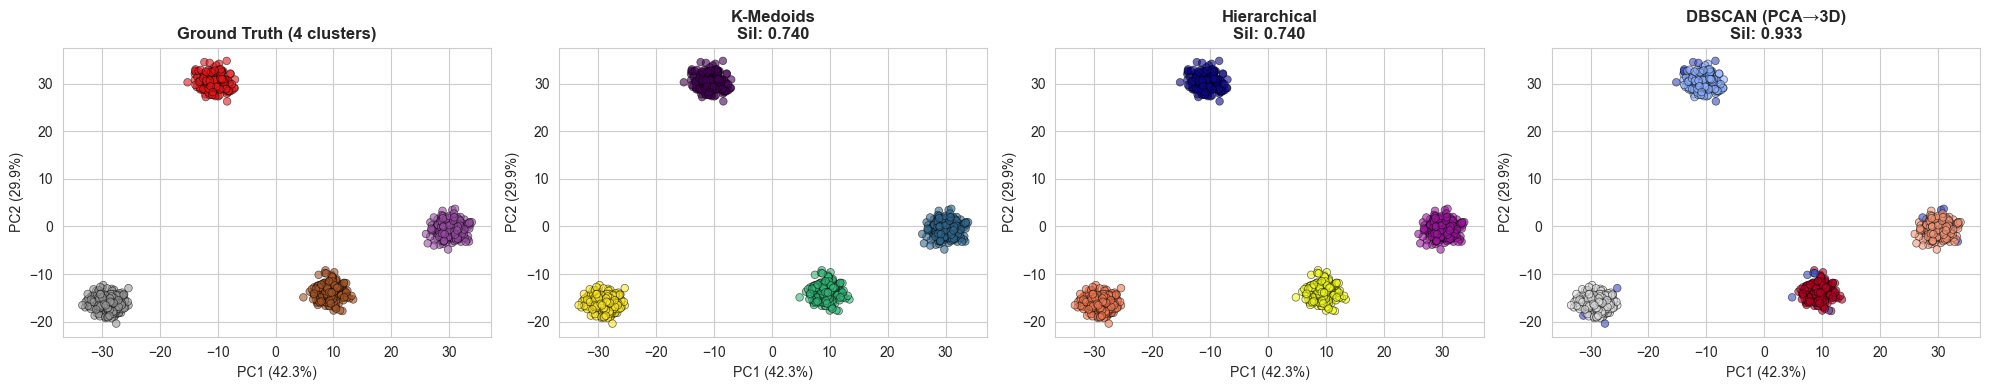


✓ RESULTADOS:
  K-Medoids:    Silhouette: 0.7404 | Davies-Bouldin: 0.3765
  Hierarchical: Silhouette: 0.7404 | Davies-Bouldin: 0.3765
  DBSCAN:       Silhouette: 0.9330 | Davies-Bouldin: 0.0946

  Varianza explicada por PC1+PC2: 72.18%
  INTERPRETACIÓN: En alta dimensionalidad, K-Medoids y Hierarchical funcionan mejor


In [5]:
print("\n" + "="*70)
print("ESCENARIO 4: ALTA DIMENSIONALIDAD (SIMULA DATASET ELECTORAL)")
print("="*70)

# Generar datos de alta dimensionalidad (similar a tu dataset)
X4, y4_true = make_blobs(
    n_samples=1000,
    n_features=39,  # Igual que tu dataset real
    centers=4,
    cluster_std=1.5,
    random_state=42
)

df4 = pd.DataFrame(X4, columns=[f'feature_{i+1}' for i in range(39)])

print(f"\n✓ Dataset generado: {df4.shape[0]} muestras, {df4.shape[1]} features")
print(f"  Clusters reales: 4")
print(f"  Dimensionalidad: Similar al dataset electoral LAPOP")

# Probar algoritmos
print("\nEntrenando algoritmos...")

# K-Medoids
km4 = KMedoids(n_clusters=4, random_state=42)
km4.fit(df4)
metrics_km4 = calculate_metrics(df4, km4.labels_)

# Hierarchical
hc4 = HierarchicalClustering(n_clusters=4, linkage='ward')
hc4.fit(df4)
metrics_hc4 = calculate_metrics(df4, hc4.labels_)

# DBSCAN (necesita eps adaptado)
print("\nDBSCAN: Reduciendo dimensionalidad primero...")

from sklearn.decomposition import PCA

pca_dbscan = PCA(n_components=0.85, random_state=42) 
X4_reduced = pca_dbscan.fit_transform(df4)

print(f"  Dimensiones reducidas: 39 → {X4_reduced.shape[1]}")
print(f"  Varianza explicada: {pca_dbscan.explained_variance_ratio_.sum()*100:.1f}%")

from sklearn.neighbors import NearestNeighbors

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X4_reduced)
distances, _ = nbrs.kneighbors(X4_reduced)
distances_sorted = np.sort(distances[:, k-1], axis=0)

eps_optimo = np.percentile(distances_sorted, 95)
print(f"  eps calculado: {eps_optimo:.3f}")

# 3. Aplicar DBSCAN en espacio reducido
db4 = DBSCAN(eps=eps_optimo, min_samples=k)
db4.fit(X4_reduced)

print(f"  Clusters encontrados: {db4.n_clusters_}")
print(f"  Puntos de ruido: {np.sum(db4.labels_ == -1)}")

# 4. Calcular métricas
if db4.n_clusters_ >= 2:
    mask = db4.labels_ != -1
    metrics_db4 = calculate_metrics(
        pd.DataFrame(X4_reduced[mask]), 
        db4.labels_[mask]
    )
    print(f"  Silhouette: {metrics_db4['silhouette']:.4f}")
else:
    metrics_db4 = None
    print("  ⚠ No se encontraron clusters válidos")

# Reducir a 2D para visualizar
print("\nReduciendo a 2D con PCA para visualización...")
pca = PCA(n_components=2, random_state=42)
X4_2d = pca.fit_transform(X4)

# Visualizar
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Ground truth
axes[0].scatter(X4_2d[:, 0], X4_2d[:, 1], c=y4_true, cmap='Set1', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title('Ground Truth (4 clusters)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

# K-Medoids
axes[1].scatter(X4_2d[:, 0], X4_2d[:, 1], c=km4.labels_, cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'K-Medoids\nSil: {metrics_km4["silhouette"]:.3f}', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

# Hierarchical
axes[2].scatter(X4_2d[:, 0], X4_2d[:, 1], c=hc4.labels_, cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'Hierarchical\nSil: {metrics_hc4["silhouette"]:.3f}', fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

# DBSCAN
if db4.n_clusters_ >= 2:
    axes[3].scatter(X4_2d[:, 0], X4_2d[:, 1], c=db4.labels_, 
                    cmap='coolwarm', alpha=0.6, s=30, 
                    edgecolors='black', linewidth=0.5)
    axes[3].set_title(
        f'DBSCAN (PCA→{X4_reduced.shape[1]}D)\n'
        f'Sil: {metrics_db4["silhouette"]:.3f}', 
        fontweight='bold'
    )
else:
    axes[3].scatter(X4_2d[:, 0], X4_2d[:, 1], c='gray', alpha=0.3, s=30)
    axes[3].set_title('DBSCAN\n(Sin clusters)', fontweight='bold')

axes[3].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[3].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig('../../figures/escenario4_alta_dimensionalidad.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ RESULTADOS:")
print(f"  K-Medoids:    Silhouette: {metrics_km4['silhouette']:.4f} | Davies-Bouldin: {metrics_km4['davies_bouldin']:.4f}")
print(f"  Hierarchical: Silhouette: {metrics_hc4['silhouette']:.4f} | Davies-Bouldin: {metrics_hc4['davies_bouldin']:.4f}")
if db4.n_clusters_ >= 2:
    print(f"  DBSCAN:       Silhouette: {metrics_db4['silhouette']:.4f} | Davies-Bouldin: {metrics_db4['davies_bouldin']:.4f}")
else:
    print(f"  DBSCAN:       Sin clusters válidos")

print(f"\n  Varianza explicada por PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("  INTERPRETACIÓN: En alta dimensionalidad, K-Medoids y Hierarchical funcionan mejor")
print("="*70)


ESCENARIO 5: ROBUSTEZ A OUTLIERS

✓ Dataset generado: 550 muestras
  Clusters reales: 3 + 50 outliers inyectados (9.1%)
Entrenando K-Medoids con 3 clusters...
✓ K-Medoids entrenado: 3 clusters identificados
  Inercia: 995.9270
Calculando métricas de validación...
  Muestras: 550
  Clusters: 3
  ✓ Silhouette Score: 0.8084
  ✓ Davies-Bouldin Index: 0.2497
  ✓ Calinski-Harabasz Index: 3380.4318
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 550
  Clusters: 3
  ✓ Silhouette Score: 0.8029
  ✓ Davies-Bouldin Index: 0.2606
  ✓ Calinski-Harabasz Index: 3171.1914
Entrenando DBSCAN (eps=0.7819375661802708, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 3
  Puntos de ruido: 46 (8.36%)
  Puntos core: 495
Calculando métricas de validación...
  Muestras: 504
  Clusters: 3
  ✓ Silhouette Score: 0.8752
  ✓ Davies-Bouldin Index: 0.1769
  ✓ Calinski-Harabasz Index: 13280.8222

  DBSCAN detectó co

C:\Users\pabli\AppData\Local\Temp\ipykernel_3284\4109395988.py:83: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\pabli\AppData\Local\Temp\ipykernel_3284\4109395988.py:84: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.savefig('../../figures/escenario5_outliers.png', dpi=300, bbox_inches='tight')
c:\electocluster\venv_clustering\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


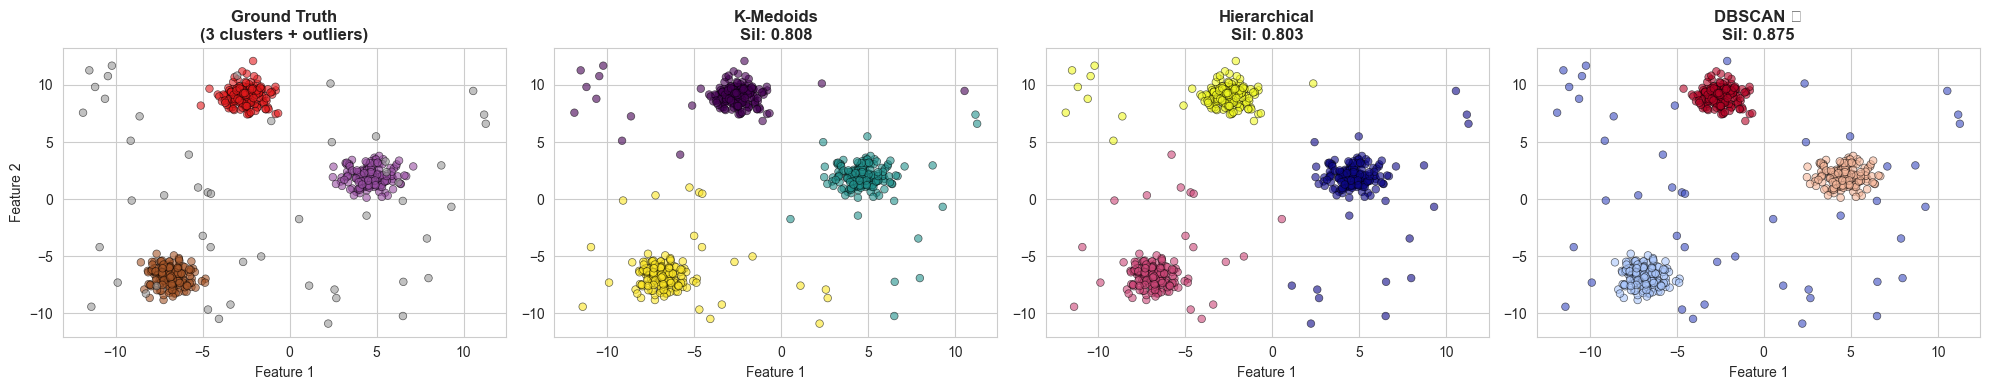


✓ RESULTADOS:
  K-Medoids:    Silhouette: 0.8084
  Hierarchical: Silhouette: 0.8029
  DBSCAN:       Silhouette: 0.8752 | Ruido: 46 puntos

  INTERPRETACIÓN: DBSCAN identifica outliers como ruido explícitamente.
  K-Medoids es más robusto que K-Means porque usa puntos reales
  como centros, reduciendo el impacto de valores extremos.


In [8]:
print("\n" + "="*70)
print("ESCENARIO 5: ROBUSTEZ A OUTLIERS")
print("="*70)

# Clusters normales con outliers inyectados
X5_base, y5_true = make_blobs(
    n_samples=500,
    n_features=2,
    centers=3,
    cluster_std=0.8,
    random_state=42
)

# Inyección de 50 outliers en posiciones extremas
rng = np.random.RandomState(42)
outliers = rng.uniform(low=-12, high=12, size=(50, 2))
X5 = np.vstack([X5_base, outliers])
# Etiquetas ground truth: clusters 0,1,2 + clase 3 para outliers
y5_gt = np.concatenate([y5_true, np.full(50, 3)])

df5 = pd.DataFrame(X5, columns=['feature_1', 'feature_2'])

print(f"\n✓ Dataset generado: {df5.shape[0]} muestras")
print(f"  Clusters reales: 3 + 50 outliers inyectados ({50/len(df5)*100:.1f}%)")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Ground truth
axes[0].scatter(X5[:, 0], X5[:, 1], c=y5_gt, cmap='Set1',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title('Ground Truth\n(3 clusters + outliers)', fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# K-Medoids — teóricamente más robusto a outliers que K-Means
km5 = KMedoids(n_clusters=3, random_state=42)
km5.fit(df5)
metrics_km5 = calculate_metrics(df5, km5.labels_)

axes[1].scatter(X5[:, 0], X5[:, 1], c=km5.labels_, cmap='viridis',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'K-Medoids\nSil: {metrics_km5["silhouette"]:.3f}', fontweight='bold')
axes[1].set_xlabel('Feature 1')

# Hierarchical
hc5 = HierarchicalClustering(n_clusters=3, linkage='ward')
hc5.fit(df5)
metrics_hc5 = calculate_metrics(df5, hc5.labels_)

axes[2].scatter(X5[:, 0], X5[:, 1], c=hc5.labels_, cmap='plasma',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'Hierarchical\nSil: {metrics_hc5["silhouette"]:.3f}', fontweight='bold')
axes[2].set_xlabel('Feature 1')

# DBSCAN — debería identificar outliers como ruido (-1)
from sklearn.neighbors import NearestNeighbors
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X5)
distances, _ = nbrs.kneighbors(X5)
eps5 = np.percentile(np.sort(distances[:, k-1]), 90)

db5 = DBSCAN(eps=eps5, min_samples=k)
db5.fit(df5)

if db5.n_clusters_ >= 2:
    mask5 = db5.labels_ != -1
    metrics_db5 = calculate_metrics(df5[mask5], db5.labels_[mask5])
    sil_text5 = f'Sil: {metrics_db5["silhouette"]:.3f}'

    # Verificar cuántos outliers reales fueron detectados como ruido
    outliers_detectados = np.sum(db5.labels_[500:] == -1)
    print(f"\n  DBSCAN detectó como ruido: {db5.n_noise_points_} puntos")
    print(f"  De esos, outliers reales correctamente identificados: "
          f"{outliers_detectados}/50 ({outliers_detectados/50*100:.1f}%)")
else:
    sil_text5 = 'Sin clusters'

axes[3].scatter(X5[:, 0], X5[:, 1], c=db5.labels_, cmap='coolwarm',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[3].set_title(f'DBSCAN ✓\n{sil_text5}', fontweight='bold')
axes[3].set_xlabel('Feature 1')

plt.tight_layout()
plt.savefig('../../figures/escenario5_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ RESULTADOS:")
print(f"  K-Medoids:    Silhouette: {metrics_km5['silhouette']:.4f}")
print(f"  Hierarchical: Silhouette: {metrics_hc5['silhouette']:.4f}")
if db5.n_clusters_ >= 2:
    print(f"  DBSCAN:       Silhouette: {metrics_db5['silhouette']:.4f} | "
          f"Ruido: {db5.n_noise_points_} puntos")

print("\n  INTERPRETACIÓN: DBSCAN identifica outliers como ruido explícitamente.")
print("  K-Medoids es más robusto que K-Means porque usa puntos reales")
print("  como centros, reduciendo el impacto de valores extremos.")
print("="*70)


ESCENARIO 6: CLUSTERS DESBALANCEADOS

✓ Dataset generado: 850 muestras
  Distribución real: 700 / 80 / 70 (muy desbalanceado)
  Simula la estructura observada en el dataset electoral
Entrenando K-Medoids con 3 clusters...
✓ K-Medoids entrenado: 3 clusters identificados
  Inercia: 1463.9380
Calculando métricas de validación...
  Muestras: 850
  Clusters: 3
  ✓ Silhouette Score: 0.8123
  ✓ Davies-Bouldin Index: 0.2076
  ✓ Calinski-Harabasz Index: 3151.0999
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 850
  Clusters: 3
  ✓ Silhouette Score: 0.8123
  ✓ Davies-Bouldin Index: 0.2076
  ✓ Calinski-Harabasz Index: 3151.0999
Entrenando DBSCAN (eps=0.4175749580646205, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 3
  Puntos de ruido: 45 (5.29%)
  Puntos core: 765
Calculando métricas de validación...
  Muestras: 805
  Clusters: 3
  ✓ Silhouette Score: 0.8224
  ✓ Davies-Bouldin Index: 0.1

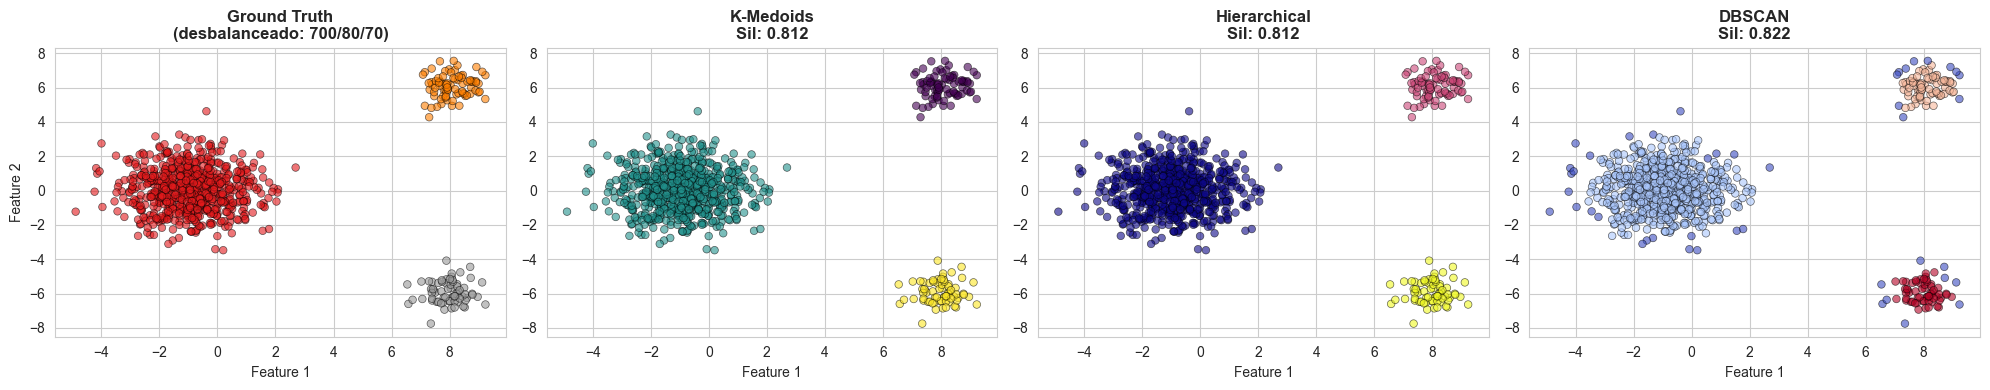


✓ RESULTADOS:
  K-Medoids:    Silhouette: 0.8123
  Hierarchical: Silhouette: 0.8123
  DBSCAN:       Silhouette: 0.8224

  Distribución K-Medoids encontrada:
 cluster  size  percentage
       0    80    9.411765
       1   700   82.352941
       2    70    8.235294


In [10]:
print("\n" + "="*70)
print("ESCENARIO 6: CLUSTERS DESBALANCEADOS")
print("="*70)

# Un cluster dominante + grupos pequeños
X6, y6_true = make_blobs(
    n_samples=[700, 80, 70],
    centers=[[-1, 0], [8, 6], [8, -6]],
    cluster_std=[1.2, 0.6, 0.6],
    random_state=42
)

df6 = pd.DataFrame(X6, columns=['feature_1', 'feature_2'])

print(f"\n✓ Dataset generado: {df6.shape[0]} muestras")
print(f"  Distribución real: 700 / 80 / 70 (muy desbalanceado)")
print(f"  Simula la estructura observada en el dataset electoral")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Ground truth
axes[0].scatter(X6[:, 0], X6[:, 1], c=y6_true, cmap='Set1',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title('Ground Truth\n(desbalanceado: 700/80/70)', fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# K-Medoids
km6 = KMedoids(n_clusters=3, random_state=42)
km6.fit(df6)
metrics_km6 = calculate_metrics(df6, km6.labels_)
dist_km6 = km6.get_cluster_distribution()

axes[1].scatter(X6[:, 0], X6[:, 1], c=km6.labels_, cmap='viridis',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'K-Medoids\nSil: {metrics_km6["silhouette"]:.3f}', fontweight='bold')
axes[1].set_xlabel('Feature 1')

# Hierarchical
hc6 = HierarchicalClustering(n_clusters=3, linkage='ward')
hc6.fit(df6)
metrics_hc6 = calculate_metrics(df6, hc6.labels_)

axes[2].scatter(X6[:, 0], X6[:, 1], c=hc6.labels_, cmap='plasma',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'Hierarchical\nSil: {metrics_hc6["silhouette"]:.3f}', fontweight='bold')
axes[2].set_xlabel('Feature 1')

# DBSCAN
from sklearn.neighbors import NearestNeighbors
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X6)
distances, _ = nbrs.kneighbors(X6)
eps6 = np.percentile(np.sort(distances[:, k-1]), 90)

db6 = DBSCAN(eps=eps6, min_samples=k)
db6.fit(df6)

if db6.n_clusters_ >= 2:
    mask6 = db6.labels_ != -1
    metrics_db6 = calculate_metrics(df6[mask6], db6.labels_[mask6])
    sil_text6 = f'Sil: {metrics_db6["silhouette"]:.3f}'
else:
    sil_text6 = 'Sin clusters'

axes[3].scatter(X6[:, 0], X6[:, 1], c=db6.labels_, cmap='coolwarm',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[3].set_title(f'DBSCAN\n{sil_text6}', fontweight='bold')
axes[3].set_xlabel('Feature 1')

plt.tight_layout()
plt.savefig('../../figures/escenario6_desbalanceado.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ RESULTADOS:")
print(f"  K-Medoids:    Silhouette: {metrics_km6['silhouette']:.4f}")
print(f"  Hierarchical: Silhouette: {metrics_hc6['silhouette']:.4f}")
if db6.n_clusters_ >= 2:
    print(f"  DBSCAN:       Silhouette: {metrics_db6['silhouette']:.4f}")
print(f"\n  Distribución K-Medoids encontrada:")
print(dist_km6.to_string(index=False))

### RESUMEN Y METRICAS FINALES

In [ ]:
print("\n" + "="*70)
print("RESUMEN COMPARATIVO DE ESCENARIOS")
print("="*70)

# Resumen
summary_data = {
    'Escenario': [
        '1. Clusters separados',
        '2. Lunas (no convexo)',
        '3. Círculos anidados',
        '4. Alta dimensionalidad',
        '5. Con outliers',          
        '6. Desbalanceados'         
    ],
    'K-Medoids': [
        f"{metrics_km1['silhouette']:.3f}",
        f"{metrics_km2['silhouette']:.3f}",
        f"{metrics_km3['silhouette']:.3f}",
        f"{metrics_km4['silhouette']:.3f}",
        f"{metrics_km5['silhouette']:.3f}",
        f"{metrics_km6['silhouette']:.3f}" 
    ],
    'Hierarchical': [
        f"{metrics_hc1['silhouette']:.3f}",
        f"{metrics_hc2['silhouette']:.3f}",
        f"{metrics_hc3['silhouette']:.3f}",
        f"{metrics_hc4['silhouette']:.3f}",
        f"{metrics_hc5['silhouette']:.3f}",
        f"{metrics_hc6['silhouette']:.3f}" 
    ],
    'DBSCAN': [
        f"{metrics_db1['silhouette']:.3f}" if db1.n_clusters_ >= 2 else "N/A",
        f"{metrics_db2['silhouette']:.3f}" if db2.n_clusters_ >= 2 else "N/A",
        f"{metrics_db3['silhouette']:.3f}" if db3.n_clusters_ >= 2 else "N/A",
        f"{metrics_db4['silhouette']:.3f}" if db4.n_clusters_ >= 2 else "N/A",
        f"{metrics_db5['silhouette']:.3f}" if db5.n_clusters_ >= 2 else "N/A",
        f"{metrics_db6['silhouette']:.3f}" if db6.n_clusters_ >= 2 else "N/A" 
    ],
    'Mas adecuado': [
        'Todos',
        'DBSCAN',
        'DBSCAN',
        'K-Medoids/Hierarchical',
        'DBSCAN',          
        'K-Medoids'        
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nSilhouette Scores por Escenario:")
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("CONCLUSIONES:")
print("="*70)
print("✓ K-Medoids y Hierarchical: Mejores para clusters convexos y bien separados")
print("✓ DBSCAN: Mejor para formas arbitrarias y detección de outliers")
print("✓ Alta dimensionalidad: Favorece a métodos basados en partición")
print("✓ Dataset electoral (39D): K-Medoids o Hierarchical serian más apropiados")
print("="*70)


RESUMEN COMPARATIVO DE ESCENARIOS

Silhouette Scores por Escenario:
              Escenario K-Medoids Hierarchical DBSCAN           Mas adecuado
  1. Clusters separados     0.895        0.895  0.895                  Todos
  2. Lunas (no convexo)     0.483        0.430  0.339                 DBSCAN
   3. Círculos anidados     0.347        0.344  0.114                 DBSCAN
4. Alta dimensionalidad     0.740        0.740  0.933 K-Medoids/Hierarchical
        5. Con outliers     0.808        0.803  0.875                 DBSCAN
      6. Desbalanceados     0.812        0.812  0.822              K-Medoids

CONCLUSIONES:
✓ K-Medoids y Hierarchical: Mejores para clusters convexos y bien separados
✓ DBSCAN: Mejor para formas arbitrarias y detección de outliers
✓ Alta dimensionalidad: Favorece a métodos basados en partición
✓ Dataset electoral (39D): K-Medoids o Hierarchical son más apropiados
